In [1]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Explore 1000 genomes data

In [8]:
populations = pd.read_csv('/gpfs/commons/datasets/1000genomes/phase3/20131219.populations.tsv',sep='\t',engine='python')
superpopulations = pd.read_csv('/gpfs/commons/datasets/1000genomes/phase3/20131219.superpopulations.tsv', sep='\t',engine='python')

In [10]:
populations.groupby('Super Population')['Final Phase Samples'].sum()

Super Population
AFR    669.0
AMR    352.0
EAS    515.0
EUR    505.0
SAS    494.0
Name: Final Phase Samples, dtype: float64

Choose K=5 for admixture files; read in .ped and .map files

In [2]:
def prep_1000genomes_bed_file(root_dir, intermediate_file_dir, output_dir):
    # change map and ped files to bed format
    # major allele set to A2 (If a binary fileset was originally loaded, --keep-allele-order forces the original A1/A2 allele encoding to be preserved; otherwise, the major allele is set to A2)
    plink_extract = f'''
    module load plink/1.9 && plink --file {root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05 \
        --make-bed \
        --out {output_dir}/X
    '''
    result = subprocess.run(plink_extract, shell=True, check=True, executable="/bin/bash")


In [47]:
def calculate_maf_by_superpop(igsr_samples_filepath,intermediate_file_dir,bfile_path,read_in_existing=False):
      # Calculate allele frequencies in five superpopulations
      # generate superpopulation cluster file
      if not read_in_existing:
            print('running')
            igsr_samples = pd.read_csv(igsr_samples_filepath,sep='\t')
            igsr_samples["Superpopulation code"] = igsr_samples["Superpopulation code"].str.split(",").str[0] # chose first for sample with EUR,AFR superpopulation code
            igsr_samples.rename(columns={'Sample name':'IID'},inplace=True)
            igsr_samples['FID'] = igsr_samples['IID']
            igsr_samples[['FID','IID','Superpopulation code']].to_csv(f'{intermediate_file_dir}/superpop.clst',index=False,header=False,sep='\t')
            # calculate maf by superpop
            plink_freq = f''' module load plink/1.9 && 
            plink --bfile {bfile_path} \
                  --freq \
                  --within {intermediate_file_dir}/superpop.clst \
                  --out {intermediate_file_dir}/maf_by_superpop
            '''
            result = subprocess.run(plink_freq, shell=True, check=True, executable="/bin/bash")

      maf_by_superpop = pd.read_csv(f'{intermediate_file_dir}/maf_by_superpop.frq.strat',sep='\s+')
      return maf_by_superpop


In [51]:
maf_by_superpop

,CHR,SNP,CLST,A1,A2,MAF,MAC,NCHROBS
0,1,1:76838,AFR,G,T,0.003026,4,1322
1,1,1:76838,AMR,G,T,0.165700,115,694
2,1,1:76838,EAS,G,T,0.020830,21,1008
3,1,1:76838,EUR,G,T,0.061630,62,1006
4,1,1:76838,SAS,G,T,0.079750,78,978
...,...,...,...,...,...,...,...,...
968165,22,22:51235959,AFR,C,T,0.015890,21,1322
968166,22,22:51235959,AMR,C,T,0.108100,75,694
968167,22,22:51235959,EAS,C,T,0.274800,277,1008
968168,22,22:51235959,EUR,C,T,0.189900,191,1006


In [52]:
def sun_generate_sim_data(root_dir,igsr_samples_filepath,intermediate_file_dir,intermediate_file_suffix,output_dir,output_file_suffix,
                          ps,num_markers_assoc,e,extra_subgroups_size,M,num_clinical_assoc, K=5):
    '''
    Generate synthetic data similar to Sun et al. (Multi-view biclustering for genotype-phenotype association studies of complex diseases)
    using 1000 Genomes Phase 3 data. Use admixture files which contain 193634 markers with MAF>5% and 2504 individuals. 

    PARAMS:
    root_dir: root directory for 1000 Genomes data
    igsr_samples_filepath: file path to igsr_samples.tsv
    intermediate_file_dir: dir to write intermediate files to (when using plink for example)
    intermediate_file_suffix: such that if multiple simulations are created, each is distinctly defined
    intermediate_file_suffix: such that if multiple simulations are created, each is distinctly defined - suffic for C and simulated data pkl file
    output_dir: where to write output genetic data matrix (X) in form of plink bfile, and clinical data matrix C
    M: number of clinical features (right now assuming all from one domain & all binary)
    ps: variable controlling how much population stratification is affecting geno-pheno relationship (needs to be in range(0,1,size=0.1)) 
    (0-> pick SNPs in bottom 10% by allele frequency variance i.e. little pop. strat., 0.9-> pick SNPS in top 10% by allele frequency variance i.e. large pop. strat.)
    num_markers_assoc: number of markers with an associated with subtype classification (if rij>int(0.4*markers_assoc) then subject i in subgroup j)
    e: relative effect that genetic variation contributed to the effect of the phenotype. e in [0,1]. (decreased e means higher level of disagreement between genotypic and phenotypic subgroups)
    num_clinical_assoc: number of clinical features associated with subtype classification (same for all subtypes)
    extra_subgroups_size: number of people in s3 and s4 (selected at random)
    K: number of admixture groups to estimate af variance over (K in [5,26] per 1000 genomes phase 3 paper)

    outputs:
    X: genetic data bfile (writtten to {output_dir}/X)
    C: clinical data matrix (num samples x M)
    in pickle file (all simulation metadata):
    genetic_subgroups: genetic subgroup assignments for all individuals
    phenotypic_subgroups: phenotypic subgroup assignments for all individuals
    iid_order: IIDs in order (to align to clinical data matrix)
    markers_assoc_dict: for each genetic subgroup, IDs of genetic markers selected to be associated
    clinical_assoc_df: for each phenotypic subgroup, index of clinical variables selected to be associated (and their selected assoc. strength)

    '''
    assert num_clinical_assoc<M, "num_clinical_assoc cannot exceed M"

    # Prepare plink bfile
    if not os.path.exists(f'{output_dir}/X.bed'):
        prep_1000genomes_bed_file(root_dir=root_dir, intermediate_file_dir=intermediate_file_dir, output_dir=output_dir)

    # 1. Read in allele frequencies per 5 superpopulations to estimate af variance across groups
    maf_by_superpop = calculate_maf_by_superpop(igsr_samples_filepath,intermediate_file_dir,bfile_path=f'{output_dir}/X',read_in_existing=True) # don't need to recalculate each time
    superpopulations = maf_by_superpop['CLST'].unique()
    maf_by_superpop = maf_by_superpop.pivot(index=['SNP'],columns='CLST',values='MAF').reset_index()
    assert maf_by_superpop.shape[0] == 193634
    maf_by_superpop['af_variance'] = maf_by_superpop[superpopulations].var(axis=1)
    maf_by_superpop['af_var_decile'] = (pd.qcut(maf_by_superpop['af_variance'], 10, labels=False))/10 # discretize into equal size buckets based on deciles


    # 2. Generate genetic subgroups
    genetic_subgroups = []
    markers_assoc_dict = {} # names of the markers that are associated with each subgroup
    for genetic_subgroup in range(2):
        # Select SNP group based on num_markers_assoc and ps
        assert maf_by_superpop[maf_by_superpop['af_var_decile']==ps].shape[0]>num_markers_assoc, f"number of genetic features assoc. ({num_markers_assoc}) is too large, only {maf_by_superpop[maf_by_superpop['af_var_decile']==ps].shape[0]} markers in decile {ps} group"
        markers_assoc = maf_by_superpop[maf_by_superpop['af_var_decile']==ps].sample(n=num_markers_assoc, replace=False)['SNP'].values.tolist()
        markers_assoc_dict[genetic_subgroup] = markers_assoc
        assert len(set(markers_assoc))==len(markers_assoc) # make sure ped file has unique rows

        
        # extract selected markers
        with open(f'{intermediate_file_dir}/markers_assoc_g{genetic_subgroup}_{intermediate_file_suffix}.txt','w') as f:
            for snp in markers_assoc:
                f.write(snp + "\n")
        
        # extract select markers and get marker values for each individual (0 - no copies of minor allele, 1 - 1 copy of minor allele, 2 - 2 copies of minor allele)
        plink_extract = f'''
        module load plink/1.9 && plink --bfile {intermediate_file_dir}/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05 \
            --extract {intermediate_file_dir}/markers_assoc_g{genetic_subgroup}_{intermediate_file_suffix}.txt \
            --make-bed \
            --recode A \
            --out {intermediate_file_dir}/subset_markers_g{genetic_subgroup}_{intermediate_file_suffix}
        '''
        result = subprocess.run(plink_extract, shell=True, check=True, executable="/bin/bash")

        # read in to get genotype counts
        raw = pd.read_csv(f'{intermediate_file_dir}/subset_markers_g{genetic_subgroup}_{intermediate_file_suffix}.raw',sep="\s+")
        geno = raw.drop(columns=['FID','IID','PAT','MAT','SEX','PHENOTYPE'])
        # assert they are all ≤ 0.5 (i.e., A1 is the minor allele)
        assert (geno.sum(axis=0) / (2 * geno.shape[0]) <= 0.5).all(), "Some SNPs have A1 frequency > 0.5"
        geno_cols = [col for col in raw.columns if not col in ['FID','IID','PAT','MAT','SEX','PHENOTYPE']]
        assert len(geno_cols) == num_markers_assoc
        raw[geno_cols] = (raw[geno_cols] > 0).astype(int) # recode s.t. values 1 and 2 map to 1
        genetic_subgroup_df = raw.set_index('IID')[geno_cols].sum(axis=1).reset_index(name=f'r')
        genetic_subgroup_df['genetic_subgroup'] = genetic_subgroup
        
        deciles, bins = pd.qcut(genetic_subgroup_df["r"], 10, labels=False, retbins=True)
        genetic_subgroup_df[f'subgroup'] =genetic_subgroup_df['r']>bins[-3] # Top 20% of people per r
        genetic_subgroups.append(genetic_subgroup_df)
    genetic_subgroups = pd.concat(genetic_subgroups)

    # 3. Generate phenotypic subgroups
    iid_order = raw.IID.values # can use raw file from whichever subgroup, since IID always in same order
    # can just use bins[-4] - somewhat equivalent to 7.5
    phenotypic_subgroups = []
    for phenotypic_subgroup in range(2):
        phenotypic_subgroup_df = genetic_subgroups[genetic_subgroups['genetic_subgroup']==phenotypic_subgroup][['IID','r']].copy()
        phenotypic_subgroup_df['phenotypic_subgroup'] = phenotypic_subgroup
        phenotypic_subgroup_df['subgroup'] = phenotypic_subgroup_df['r']*e + np.random.randn(len(phenotypic_subgroup_df)) > bins[-4]*e
        phenotypic_subgroups.append(phenotypic_subgroup_df)
    for phenotypic_subgroup in range(2,4):
        # randomly select extra_subgroups_size people
        randomly_selected = pd.Series(iid_order).sample(extra_subgroups_size).values.tolist() 
        phenotypic_subgroup_df = pd.DataFrame(iid_order,columns=['IID'])
        phenotypic_subgroup_df['r'] = None
        phenotypic_subgroup_df['phenotypic_subgroup'] = phenotypic_subgroup
        phenotypic_subgroup_df['subgroup'] = phenotypic_subgroup_df['IID'].isin(randomly_selected)
        phenotypic_subgroups.append(phenotypic_subgroup_df)
    phenotypic_subgroups = pd.concat(phenotypic_subgroups)

    # 4. simulate M binary clinical features
    # start with baseline probabiliyies
    probs = np.full((len(iid_order), M), 0.1, dtype=float) # baseline prob of clinical feature is 0.1
    clinical_assoc_df_rows = [] # index of clinical vars that are associated (and their strength)
    for phenotypic_subgroup in range(4):
        # index of randomly chosen, associated clinical variables 
        assoc_idx = np.random.choice(M, size=num_clinical_assoc, replace=False) 
        np.random.shuffle(assoc_idx)       
        n1 = num_clinical_assoc // 3 # 1/3 who get P 0.6
        n2 = 2 * num_clinical_assoc // 3 # 1/3 who get P 0.5
        # get those who are in the subgroup
        mask = ((phenotypic_subgroups["phenotypic_subgroup"] == phenotypic_subgroup) & (phenotypic_subgroups["subgroup"]))
        subj_ids = phenotypic_subgroups.loc[mask, "IID"].unique()
        # map subject IDs to row indices # TODO: pick up from here
        row_idx = [i for i, iid in enumerate(iid_order) if iid in subj_ids]
        probs[np.ix_(row_idx, assoc_idx[:n1])] = 0.6
        probs[np.ix_(row_idx, assoc_idx[n1:n2])] = 0.5
        probs[np.ix_(row_idx, assoc_idx[n2:])] = 0.4
        clinical_assoc_df_rows += [
        {"phenotypic_subgroup": phenotypic_subgroup, "strength": 0.6, "indices": assoc_idx[:n1]},
        {"phenotypic_subgroup": phenotypic_subgroup, "strength": 0.5, "indices": assoc_idx[n1:n2]},
        {"phenotypic_subgroup": phenotypic_subgroup, "strength": 0.4, "indices": assoc_idx[n2:]},
        ]
    clinical_assoc_df = pd.DataFrame(clinical_assoc_df_rows)

    # write C
    C = (np.random.rand(len(iid_order), M) < probs).astype(int)
    np.save(f"{output_dir}/C_{output_file_suffix}.npy", C)

    # write simulation metadata
    bundle = {
    "iid_order": iid_order,                          # list/array
    "genetic_subgroups": genetic_subgroups,          # list/array/Series
    "phenotypic_subgroups": phenotypic_subgroups,    # list/array/Series
    "markers_assoc": markers_assoc_dict,             # dict: gen_subgroup -> [marker_id, ...]
    "clinical_assoc": clinical_assoc_df              # pandas DataFrame
    }
    with open(f"{output_dir}/simulation_metadata_{output_file_suffix}.pkl", "wb") as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

    return genetic_subgroups, phenotypic_subgroups, C, iid_order, markers_assoc_dict, clinical_assoc_df 
    

In [ ]:
intermediate_file_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'

genetic_subgroups,phenotypic_subgroups,C,iid_order,markers_assoc_dict, clinical_assoc_df = sun_generate_sim_data(root_dir=root_dir, intermediate_file_dir=intermediate_file_dir, intermediate_file_suffix='',
                                        output_dir = output_dir,  output_file_suffix='TEST',
                                      ps=0, num_markers_assoc=2000, e=0.5,extra_subgroups_size=200, M=100,num_clinical_assoc=10, K=5) # intermediate_file_suffix important if run in parallel


PLINK v1.90b6.21 64-bit (19 Oct 2020)          www.cog-genomics.org/plink/1.9/
(C) 2005-2020 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/X.log.
Options in effect:
  --file /gpfs/commons/datasets/1000genomes/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05
  --make-bed
  --out /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/X

257824 MB RAM detected; reserving 128912 MB for main workspace.
.ped scan complete (for binary autoconversion).0101010101010101010101010111111111111111111111111111111111111111111111111111212121212121212121212121212121212121212121212121213131313131313131313131313131313131313131313131313141414141414141414141414141414141414141414141414141515151515151515151515151515151515151515151515151516161616161616161616161616161616161616161616161616171717171717171717171717171717171717171

## Determine the effect of ps on confounding by superpopulation

In [5]:
igsr_samples = pd.read_csv(f'/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv',sep='\t')
igsr_samples = igsr_samples[igsr_samples['Sample name'].isin(iid_order)].copy()
igsr_samples["Sample name"] = pd.Categorical(igsr_samples["Sample name"], categories=iid_order, ordered=True)
igsr_samples = igsr_samples.sort_values("Sample name").reset_index(drop=True)
igsr_samples.head()

,Sample name,Sex,Biosample ID,Population code,Population name,Superpopulation code,Superpopulation name,Population elastic ID,Data collections
0,HG02922,female,SAME1839441,ESN,Esan,AFR,African Ancestry,ESN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
1,HG02923,male,SAME1839436,ESN,Esan,AFR,African Ancestry,ESN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
2,HG02938,male,SAME1839284,ESN,Esan,AFR,African Ancestry,ESN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3,HG02941,male,SAME1839096,ESN,Esan,AFR,African Ancestry,ESN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
4,HG02943,female,SAME1839085,ESN,"Esan,Esan",AFR,"African Ancestry,Africa (SGDP)","ESN,EsanSGDP","1000 Genomes on GRCh38,Simons Genome Diversity..."


PLINK v1.90b6.21 64-bit (19 Oct 2020)          www.cog-genomics.org/plink/1.9/
(C) 2005-2020 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/subset_markers_g0_.log.
Options in effect:
  --bfile /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05
  --extract /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/markers_assoc_g0_.txt
  --make-bed
  --out /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/subset_markers_g0_
  --recode A

257824 MB RAM detected; reserving 128912 MB for main workspace.
193634 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_phe

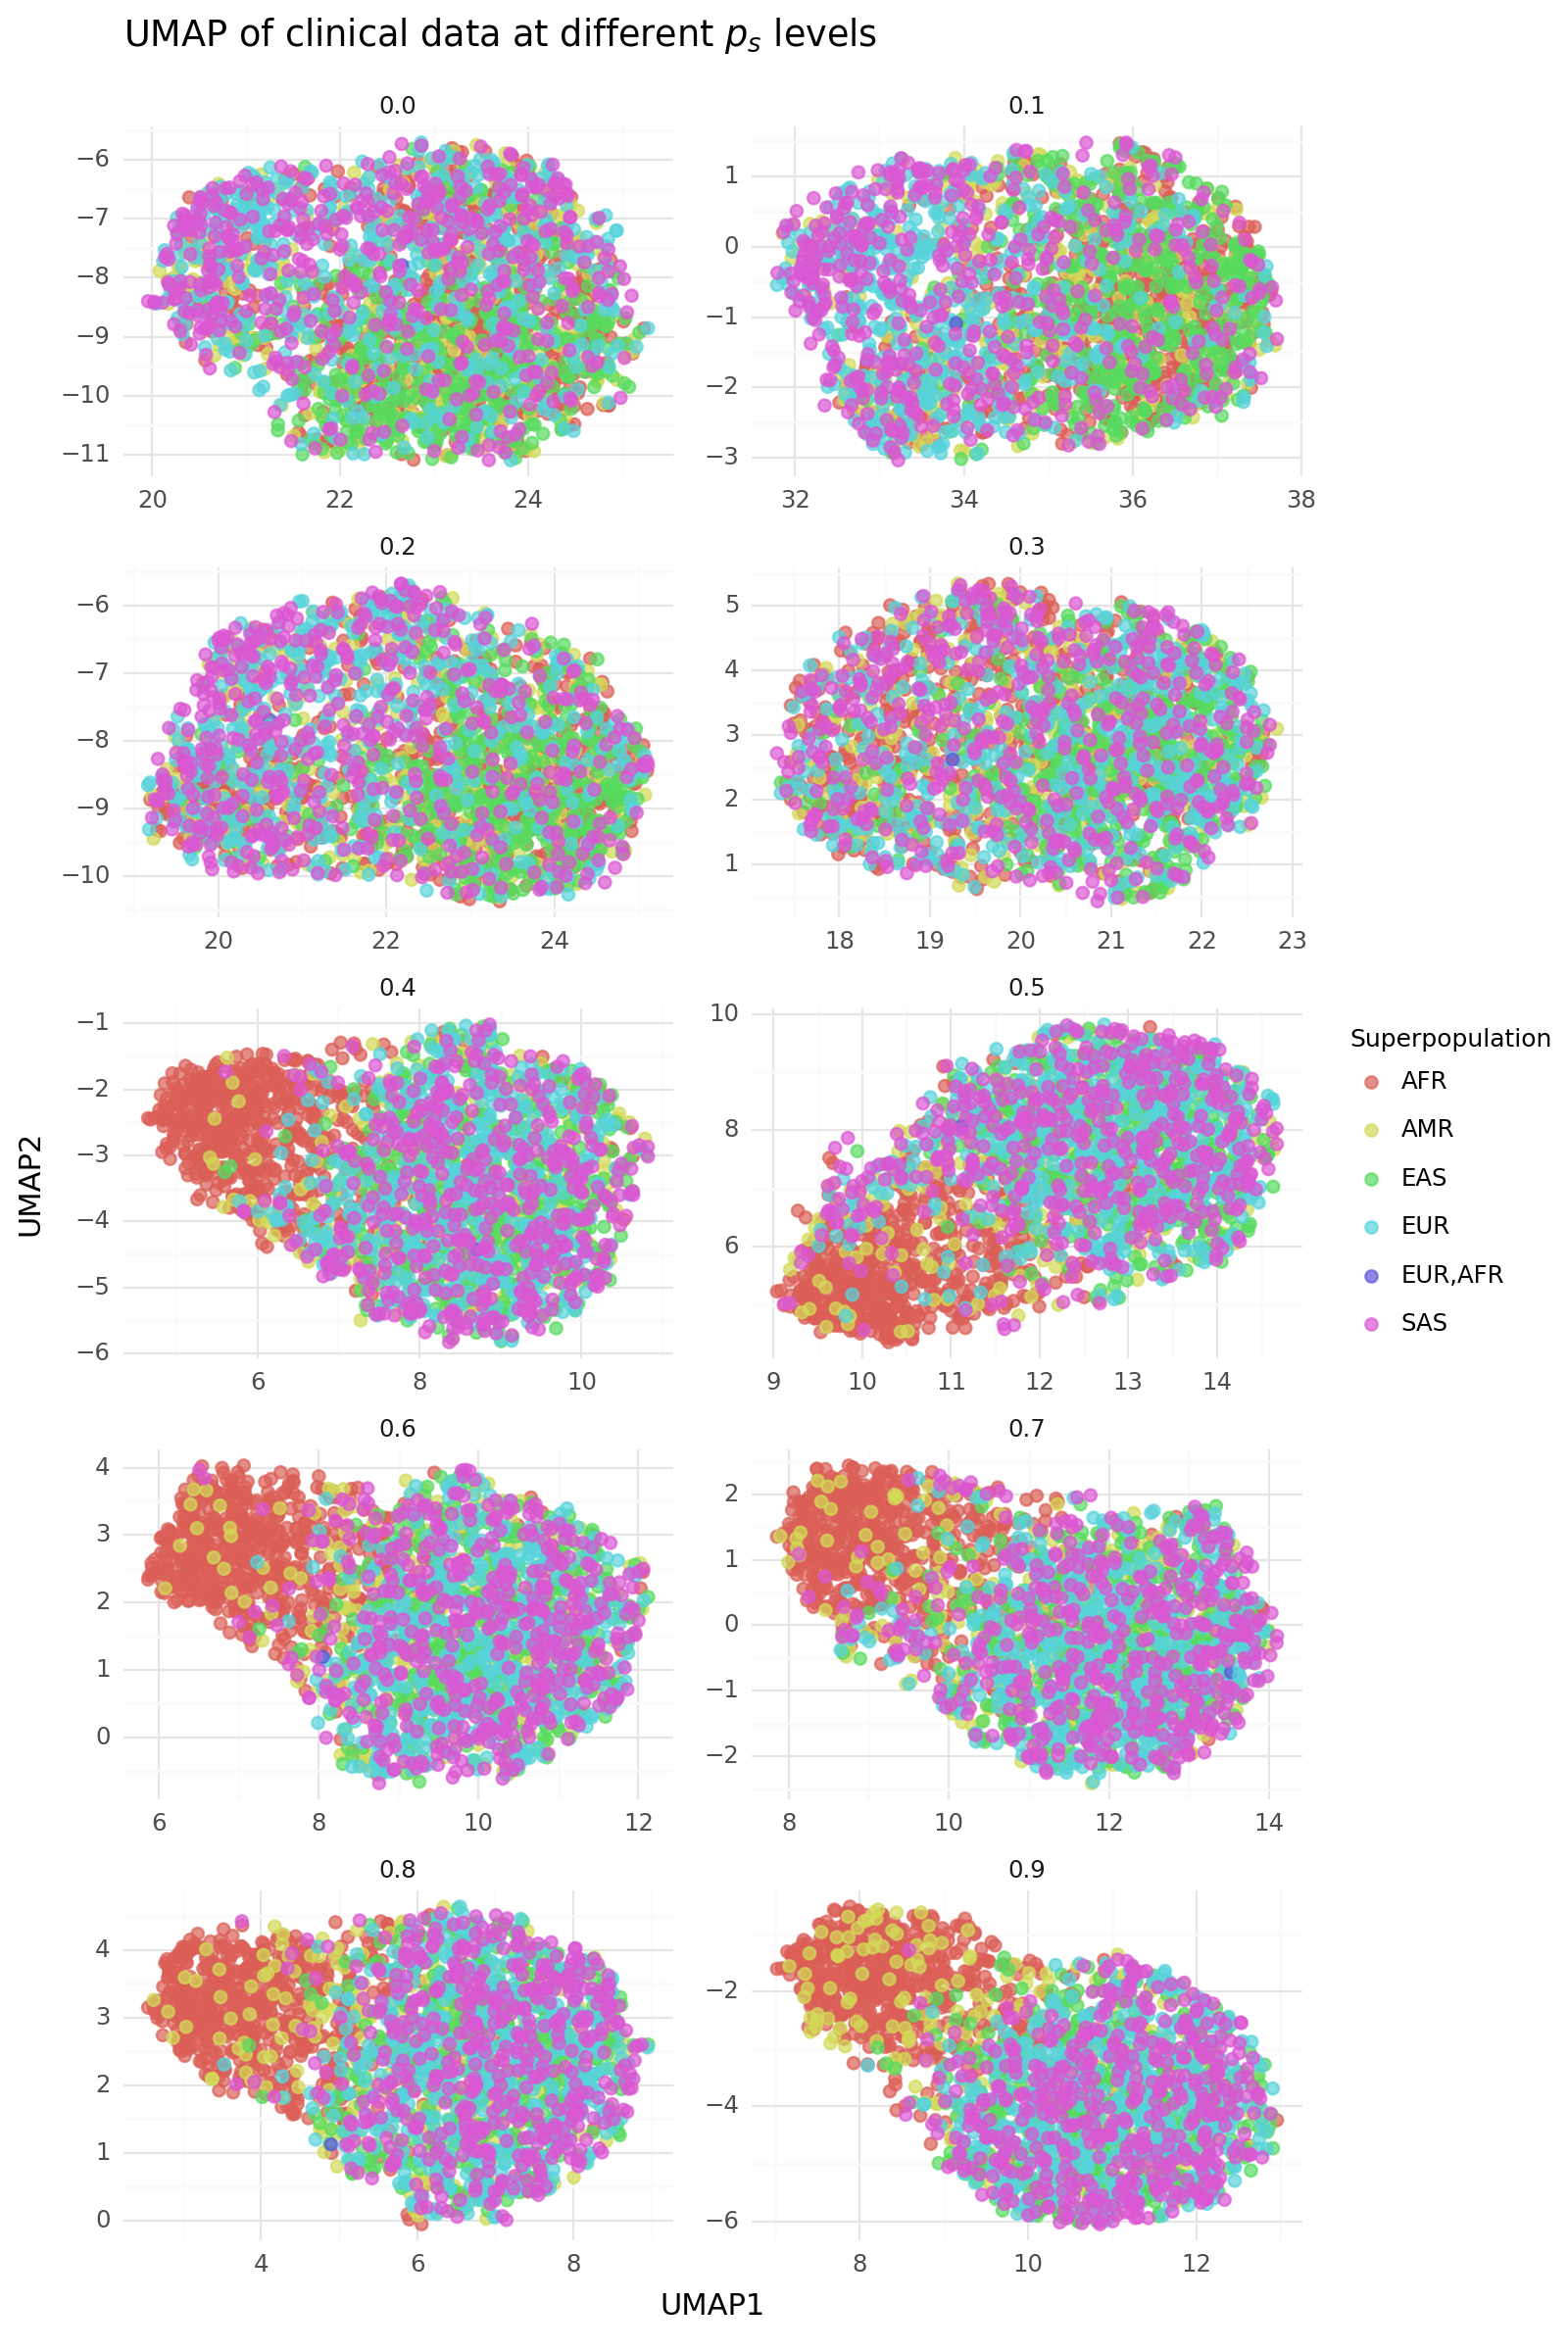

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 12 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/umap_clinical_ps.jpeg


In [28]:
plot_dfs = []
for ps in np.round(np.arange(0, 1.0, 0.1),1):
    genetic_subgroups,phenotypic_subgroups,C,iid_order, markers_assoc_dict, clinical_assoc_df = sun_generate_sim_data(root_dir='/gpfs/commons/datasets/1000genomes', intermediate_file_dir='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink', intermediate_file_suffix='', 
                                        ps=ps, num_markers_assoc=2000, e=0.5, extra_subgroups_size=200, M=100,num_clinical_assoc=10, K=5)

    assert all(iid_order == igsr_samples['Sample name'].values) # double check iid order stays the same
    
    # Get UMAP plot
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(C)

    plot_df = (
        pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"], index=igsr_samples.index)
        .join(igsr_samples[["Superpopulation code"]])
    )
    plot_df['ps'] = ps
    plot_dfs.append(plot_df)



plot_dfs = pd.concat(plot_dfs)

# --- Plot with plotnine ---
p = (
    ggplot(plot_dfs, aes("UMAP1", "UMAP2", color="Superpopulation code"))
    + geom_point(alpha=0.7, size=2)
    + labs(title=r"UMAP of clinical data at different $p_s$ levels", color="Superpopulation")
    + facet_wrap('~ps',nrow=5,scales='free')
    + theme_minimal()
    + theme(figure_size=(8, 12),legend_title=element_text(size=9))
)
p
print(p)
p.save(f'/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/umap_clinical_ps.jpeg',dpi=300)
    
    

In [32]:
def clean_join(values):
    # remove empty strings
    vals = sorted(set(v for v in values if v != ''), key=lambda x: int(x))
    return ','.join(vals)

PLINK v1.90b6.21 64-bit (19 Oct 2020)          www.cog-genomics.org/plink/1.9/
(C) 2005-2020 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/subset_markers_g0_.log.
Options in effect:
  --bfile /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05
  --extract /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/markers_assoc_g0_.txt
  --make-bed
  --out /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/subset_markers_g0_
  --recode A

257824 MB RAM detected; reserving 128912 MB for main workspace.
193634 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_phe

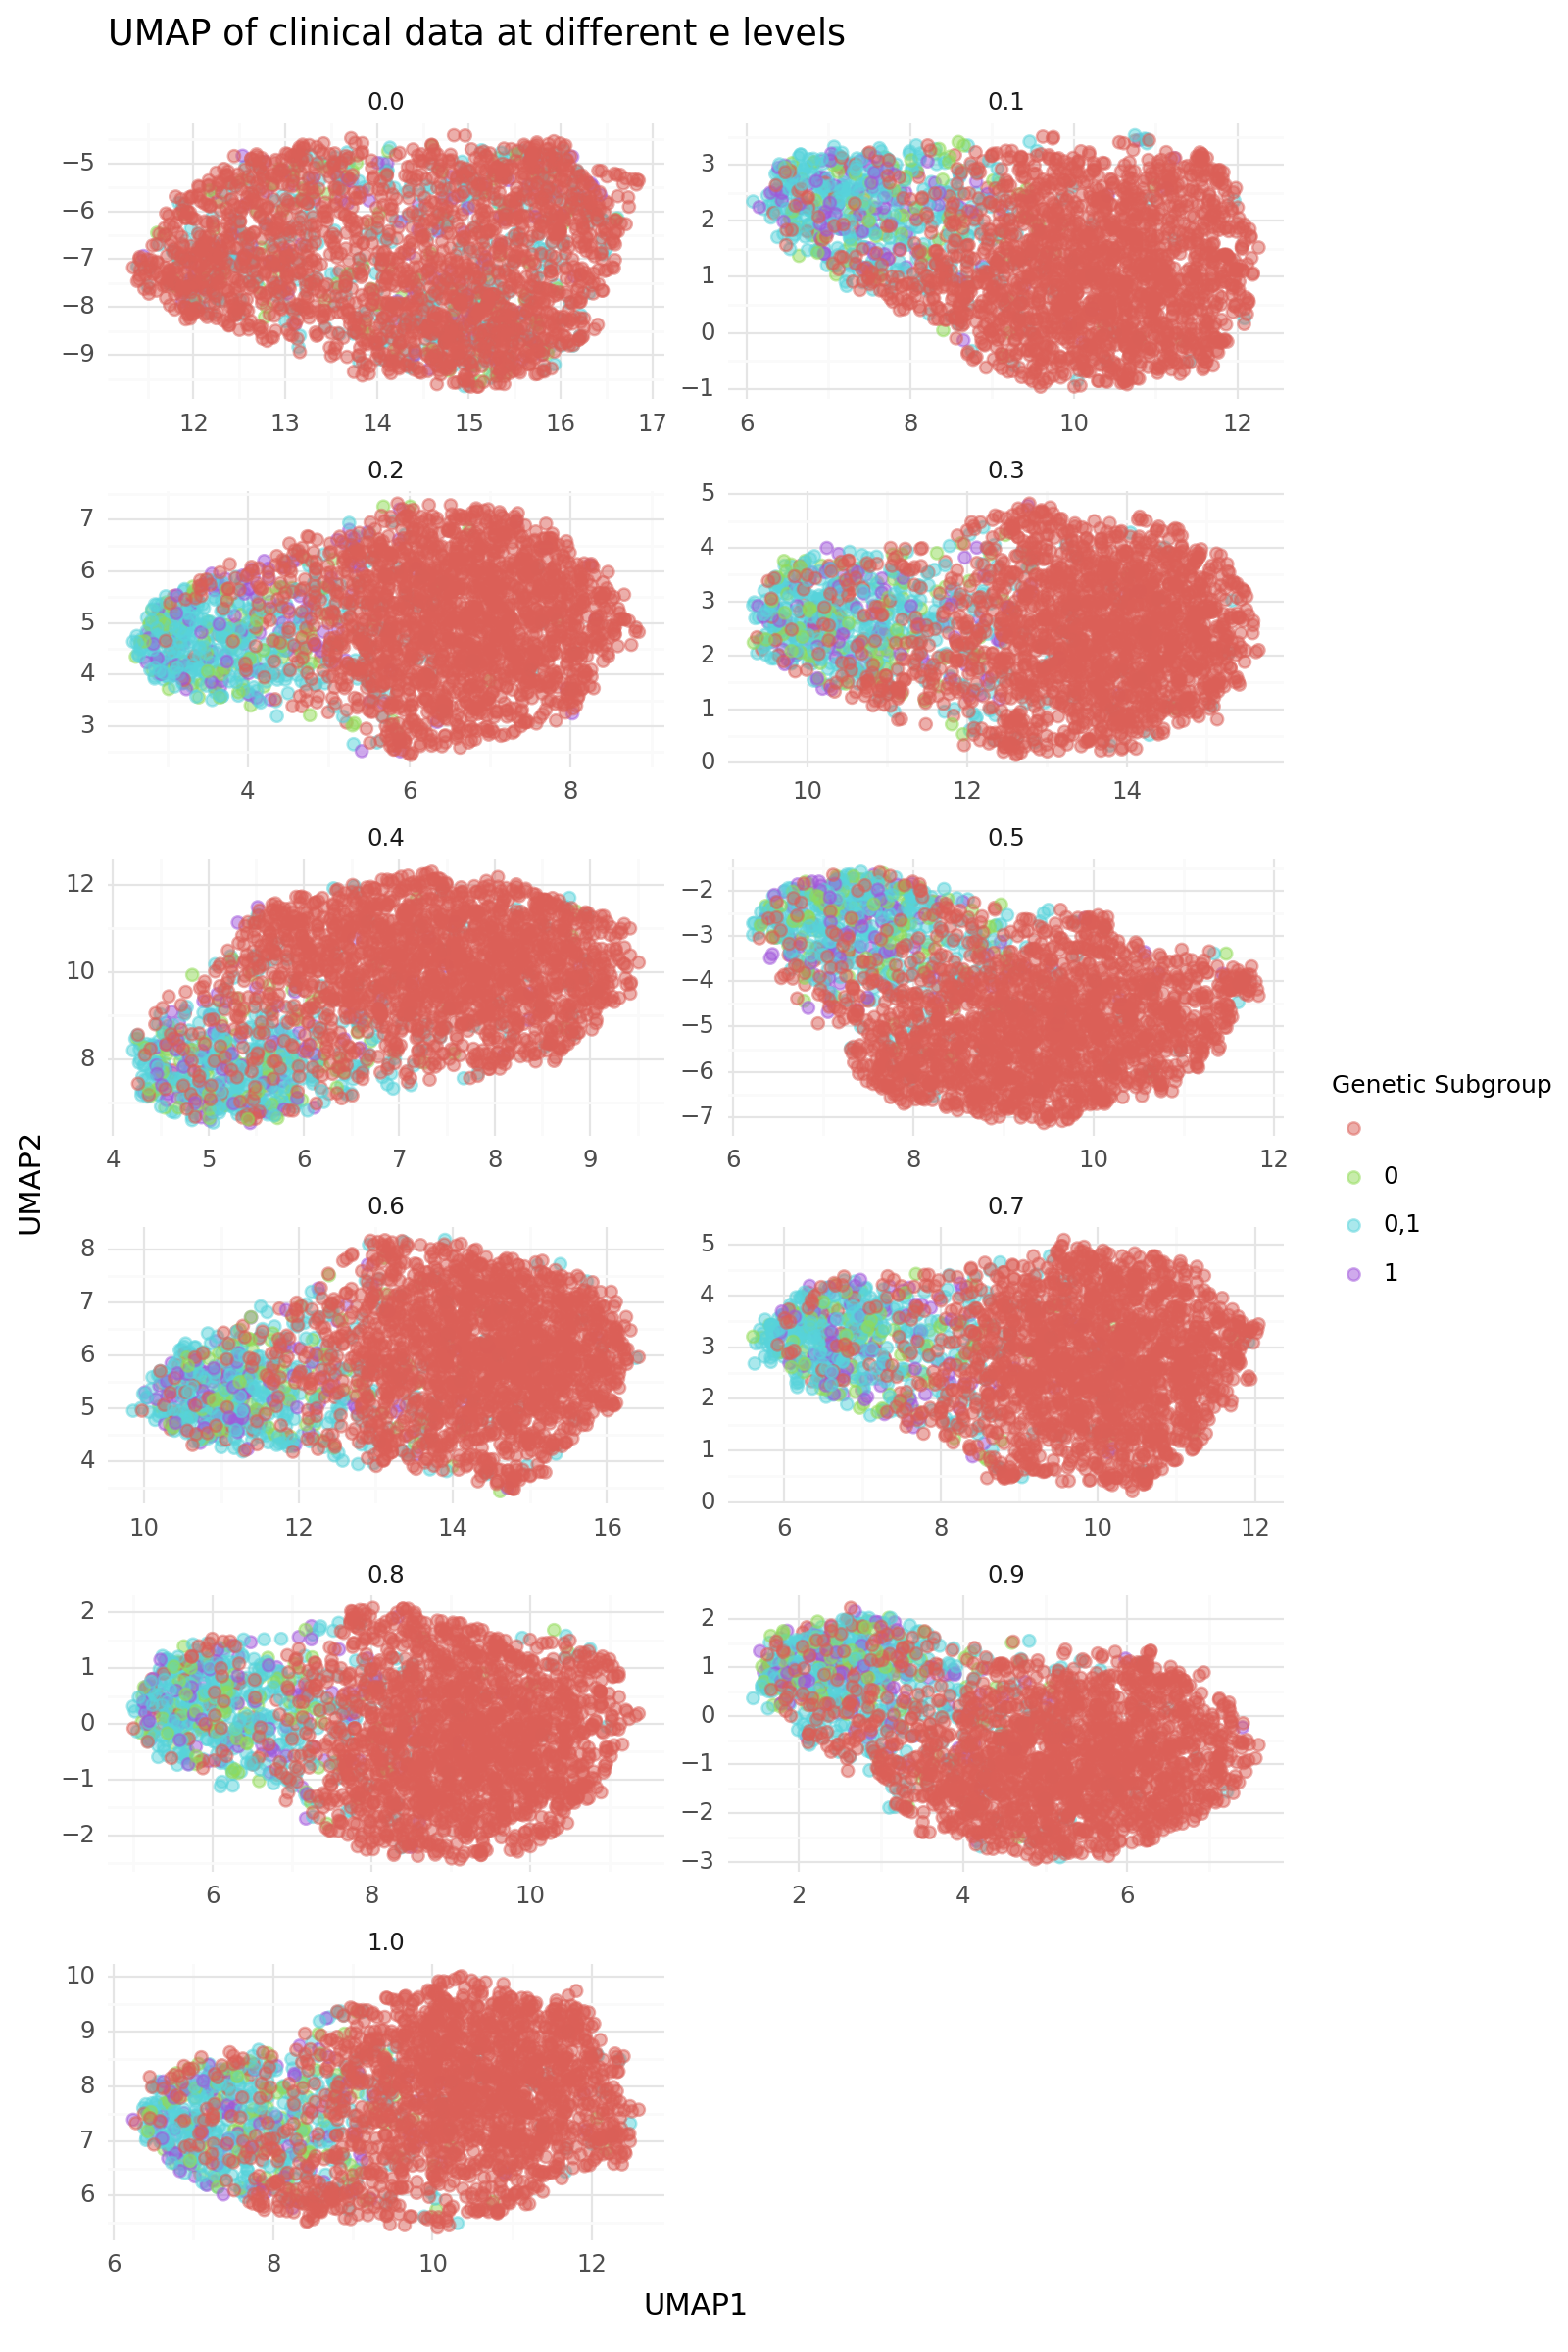

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 12 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/umap_clinical_e.jpeg


In [49]:
plot_dfs = []
for e in np.round(np.arange(0, 1.1, 0.1),1):
    genetic_subgroups,phenotypic_subgroups,C,iid_order, markers_assoc_dict, clinical_assoc_df  = sun_generate_sim_data(root_dir='/gpfs/commons/datasets/1000genomes', intermediate_file_dir='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink', intermediate_file_suffix='', 
                                        ps=0.5, num_markers_assoc=2000, e=e, extra_subgroups_size=200, M=100,num_clinical_assoc=10, K=5)
    
    # get genetic label
    genetic_subgroups['subgroup_value'] = np.where(genetic_subgroups['subgroup'],genetic_subgroups['genetic_subgroup'],'') # change this to one label per person
    genetic_subgroups_concat = genetic_subgroups.groupby('IID')['subgroup_value'].apply(clean_join).reset_index()
    genetic_subgroups_concat["IID"] = pd.Categorical(genetic_subgroups_concat["IID"], categories=iid_order, ordered=True)
    genetic_subgroups_concat = genetic_subgroups_concat.sort_values("IID").reset_index(drop=True)

    reducer = umap.UMAP()
    embedding = reducer.fit_transform(C)

    # --- Combine coords with metadata ---
    plot_df = (
        pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"], index=genetic_subgroups_concat.index)
        .join(genetic_subgroups_concat[["subgroup_value"]])
    )
    plot_df['e'] = e
    plot_dfs.append(plot_df)
plot_dfs = pd.concat(plot_dfs)
# --- Plot with plotnine ---
p = (
    ggplot(plot_dfs, aes("UMAP1", "UMAP2", color="subgroup_value"))
    + geom_point(alpha=0.5, size=2)
    + labs(title=r"UMAP of clinical data at different e levels", color="Genetic Subgroup")
    + facet_wrap('~e',nrow=6,ncol=2,scales='free')
    + theme_minimal()
    + theme(figure_size=(8, 12),legend_title=element_text(size=9))
)
p
print(p)
p.save(f'/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/umap_clinical_e.jpeg',dpi=300)
    

### Run GWAS with and without PCs and see how much genetic coefficients change 
At different levels of population stratification

In [ ]:
# TODO: switch to PCA
#result = subprocess.run(f'module unload plink && module load flashpca && cd {intermediate_file_dir} &&  flashpca --bfile {intermediate_file_dir}/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05 --ndim 20', shell=True, capture_output=True, text=True, executable='/bin/bash')


In [74]:
K = 5
covar = pd.read_csv(f"{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.{K}.Q", sep='\s+',header=None,names=[f'Fraction{i}' for i in range(K)])
covar['IID'] = iid_order
covar['FID'] = covar['IID']
covar['Sex'] = igsr_samples['Sex'].values
# probably cleaner way to do this
covar[['FID','IID']+[f'Fraction{i}' for i in range(K-1)]+['Sex']].set_index('FID').to_csv(f'{intermediate_file_dir}/COVARIATE_FILE')
covar[['FID','IID']+['Sex']].set_index('FID').to_csv(f'{intermediate_file_dir}/COVARIATE_FILE_NOPS')
# TODO: change ps - add in after have full pipeline
for cov_included in [False,True]:
    if cov_included:
        cov_file_suffix = ''
    else:
        cov_file_suffix = '_NOPS'
    for phenotypic_subgroup in [0,2]: # subgroup 0 should be affected, subgroup 2 shouldn't be affected (randomly chosen people)
        pheno = phenotypic_subgroups[phenotypic_subgroups['phenotypic_subgroup']==phenotypic_subgroup][['IID','subgroup']]
        pheno.rename(columns={'subgroup':'Phenotype'},inplace=True)
        pheno['FID'] = pheno['IID']
        pheno['Phenotype'] = pheno['Phenotype'].astype(int)
        pheno[['FID','IID','Phenotype']].set_index('FID').to_csv(f'{intermediate_file_dir}/PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}')

        # include 20 PCs
        #result = subprocess.run(f'module unload plink && module load flashpca && cd {intermediate_file_dir} &&  flashpca --bfile {intermediate_file_dir}/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05 --ndim 20', shell=True, capture_output=True, text=True, executable='/bin/bash')
        # TODO: change to PCs, for now running from superpopulation

        result = subprocess.run(f'module unload plink && module load plink/2.0a5.13 && plink --bfile {intermediate_file_dir}/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05\
                            --covar {intermediate_file_dir}/COVARIATE_FILE{cov_file_suffix} --covar-variance-standardize\
                            --pheno {intermediate_file_dir}/PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}\
                            --glm omit-ref\
                            --out {os.path.dirname(intermediate_file_dir)}/output/RESULTS_FILE_Subgroup{phenotypic_subgroup}_Geno_Cov{cov_included}\
                            --1 --no-pheno', shell=True, capture_output=True, text=True, executable='/bin/bash')
        result.check_returncode()


for subgroup 0, what's the difference in coeff effect size when covs included or not

In [79]:
# general idea: fit crude and adjusted model and if beta changes by more than 10%, we conclude that ancestry is a confounder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

phenotypic_subgroup = 0
all_plink_results = []
for cov_included in [False,True]:
    plink_results = pd.read_csv(f'{os.path.dirname(intermediate_file_dir)}/output/RESULTS_FILE_Subgroup{phenotypic_subgroup}_Geno_Cov{cov_included}.Phenotype.glm.logistic.hybrid',sep='\t')
    print(plink_results.shape)
    plink_results = plink_results[plink_results['TEST']=='ADD'].copy()
    plink_results['marker_assoc'] = plink_results['ID'].isin(markers_assoc_dict[phenotypic_subgroup]) # ground truth from simulations
    # using significance level 5e-8, what is the accuracy of association test
    plink_results['significant'] = plink_results['P'] < 5e-8 # predicted associated
    print(plink_results[plink_results['P'] < 5e-8].shape[0])
    accuracy = accuracy_score(plink_results["marker_assoc"], plink_results["significant"])
    precision = precision_score(plink_results["marker_assoc"], plink_results["significant"])
    recall = recall_score(plink_results["marker_assoc"], plink_results["significant"])
    f1 = f1_score(plink_results["marker_assoc"], plink_results["significant"])
    print(cov_included)
    print(accuracy)
    print(precision)
    print(recall)
    print(f1)
    plink_results['cov_included'] = cov_included
    all_plink_results.append(plink_results)
all_plink_results = pd.concat(all_plink_results)

(387268, 17)
128086
False
0.3440924631004886
0.012023171931358618
0.77
0.02367664468121089
(1161804, 17)
0
True
0.989671235423531
0.0
0.0
0.0


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


In [83]:
wide = (all_plink_results
        .pivot(index='ID', columns='cov_included', values='OR')
        .rename(columns={False:'OR_no_cov', True:'OR_with_cov'})
        .reset_index()
)

# Calculate relative change
wide['relative_change'] = abs(wide['OR_with_cov'] - wide['OR_no_cov']) / wide['OR_no_cov']
print(wide['relative_change'].mean())
wide

0.7869915795402833


cov_included,ID,OR_no_cov,OR_with_cov,relative_change
0,10:10002676,0.407327,0.793863,0.948957
1,10:100033081,60.261000,0.607603,0.989917
2,10:10004698,68.774400,0.331431,0.995181
3,10:100068607,0.754749,1.165830,0.544659
4,10:100076982,0.508965,0.817929,0.607044
...,...,...,...,...
193629,9:99959341,0.811283,1.173930,0.447004
193630,9:99979829,124.290000,0.521338,0.995805
193631,9:99981843,0.515383,1.016670,0.972649
193632,9:9998777,0.437162,0.953639,1.181432


In [85]:
# should see no change wi†h this subgroup
phenotypic_subgroup = 2
all_plink_results = []
for cov_included in [False,True]:
    plink_results = pd.read_csv(f'{os.path.dirname(intermediate_file_dir)}/output/RESULTS_FILE_Subgroup{phenotypic_subgroup}_Geno_Cov{cov_included}.Phenotype.glm.logistic.hybrid',sep='\t')
    print(plink_results.shape)
    plink_results = plink_results[plink_results['TEST']=='ADD'].copy()
    plink_results['marker_assoc'] = False # ground truth from simulations
    # using significance level 5e-8, what is the accuracy of association test
    plink_results['significant'] = plink_results['P'] < 5e-8 # predicted associated
    print(plink_results[plink_results['P'] < 5e-8].shape[0])
    accuracy = accuracy_score(plink_results["marker_assoc"], plink_results["significant"])
    precision = precision_score(plink_results["marker_assoc"], plink_results["significant"])
    recall = recall_score(plink_results["marker_assoc"], plink_results["significant"])
    f1 = f1_score(plink_results["marker_assoc"], plink_results["significant"])
    print(cov_included)
    print(accuracy)
    print(precision)
    print(recall)
    print(f1)
    plink_results['cov_included'] = cov_included
    all_plink_results.append(plink_results)
all_plink_results = pd.concat(all_plink_results)

(387268, 17)
0


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.


False
1.0
0.0
0.0
0.0
(1161804, 17)
0
True
1.0
0.0
0.0
0.0


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.


In [86]:
wide = (all_plink_results
        .pivot(index='ID', columns='cov_included', values='OR')
        .rename(columns={False:'OR_no_cov', True:'OR_with_cov'})
        .reset_index()
)

# Calculate relative change
wide['relative_change'] = abs(wide['OR_with_cov'] - wide['OR_no_cov']) / wide['OR_no_cov']
print(wide['relative_change'].mean())
wide

0.029815247828271215


cov_included,ID,OR_no_cov,OR_with_cov,relative_change
0,10:10002676,1.142180,1.118660,0.020592
1,10:100033081,0.849409,0.803559,0.053979
2,10:10004698,0.686901,0.575850,0.161670
3,10:100068607,0.941181,0.875650,0.069626
4,10:100076982,0.994909,1.020650,0.025873
...,...,...,...,...
193629,9:99959341,1.286830,1.423020,0.105834
193630,9:99979829,0.730324,0.659314,0.097231
193631,9:99981843,1.011900,1.014090,0.002164
193632,9:9998777,0.975574,0.920400,0.056555


In [ ]:
# analyze with effect of ps


In [ ]:
# also check that the correct markers assoc and conditions assoc. are showing up

### Run GWAS at different levels of e and see how strength of association changes

In [93]:
import pickle
bundle = {
    "iid_order": iid_order,                          # list/array
    "genetic_subgroups": genetic_subgroups,          # list/array/Series
    "phenotypic_subgroups": phenotypic_subgroups,    # list/array/Series
    "markers_assoc": markers_assoc_dict,             # dict: gen_subgroup -> [marker_id, ...]
    "clinical_assoc": clinical_assoc_df              # pandas DataFrame
}

with open("/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/bundle.pkl", "wb") as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

# load
with open("/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/bundle.pkl", "rb") as f:
    data = pickle.load(f)
data

{'iid_order': array(['HG02922', 'HG02923', 'HG02938', ..., 'HG04210', 'HG04227',
        'HG04229'], dtype=object),
 'genetic_subgroups':           IID    r  genetic_subgroup  subgroup subgroup_value
 0     HG02922  844                 0      True              0
 1     HG02923  837                 0      True              0
 2     HG02938  867                 0      True              0
 3     HG02941  839                 0      True              0
 4     HG02943  850                 0      True              0
 ...       ...  ...               ...       ...            ...
 2499  HG04106  683                 1     False               
 2500  HG04107  722                 1     False               
 2501  HG04210  690                 1     False               
 2502  HG04227  709                 1     False               
 2503  HG04229  730                 1     False               
 
 [5008 rows x 5 columns],
 'phenotypic_subgroups':           IID     r  phenotypic_subgroup  subgroup
 0 